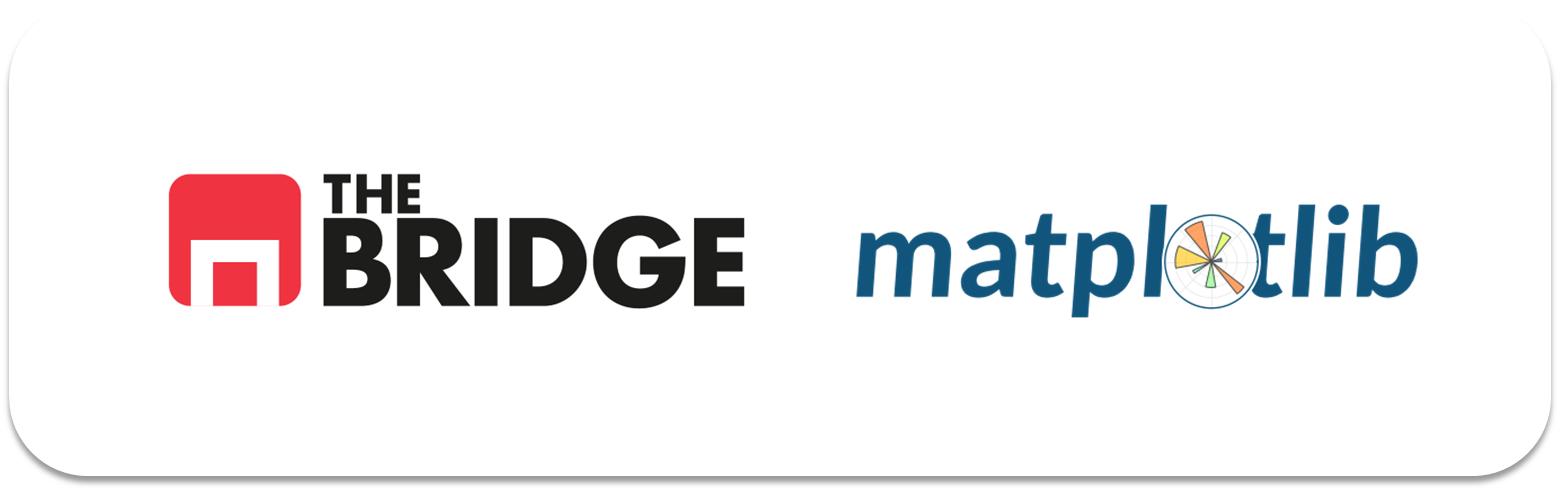

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [3]:
# Carga del dataset
df = pd.read_csv("./data/california_cities.csv")

In [5]:
# Muestra parte de su contenido y descripción
display(df.head())

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB
None


In [7]:
# Deshazte de las filas con nulos
df_clean = df.dropna().copy() # Usamos .copy() para evitar advertencias de pandas más adelante

print(f"\nFilas originales: {len(df)}, Filas tras eliminar nulos: {len(df_clean)}")


Filas originales: 482, Filas tras eliminar nulos: 427


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

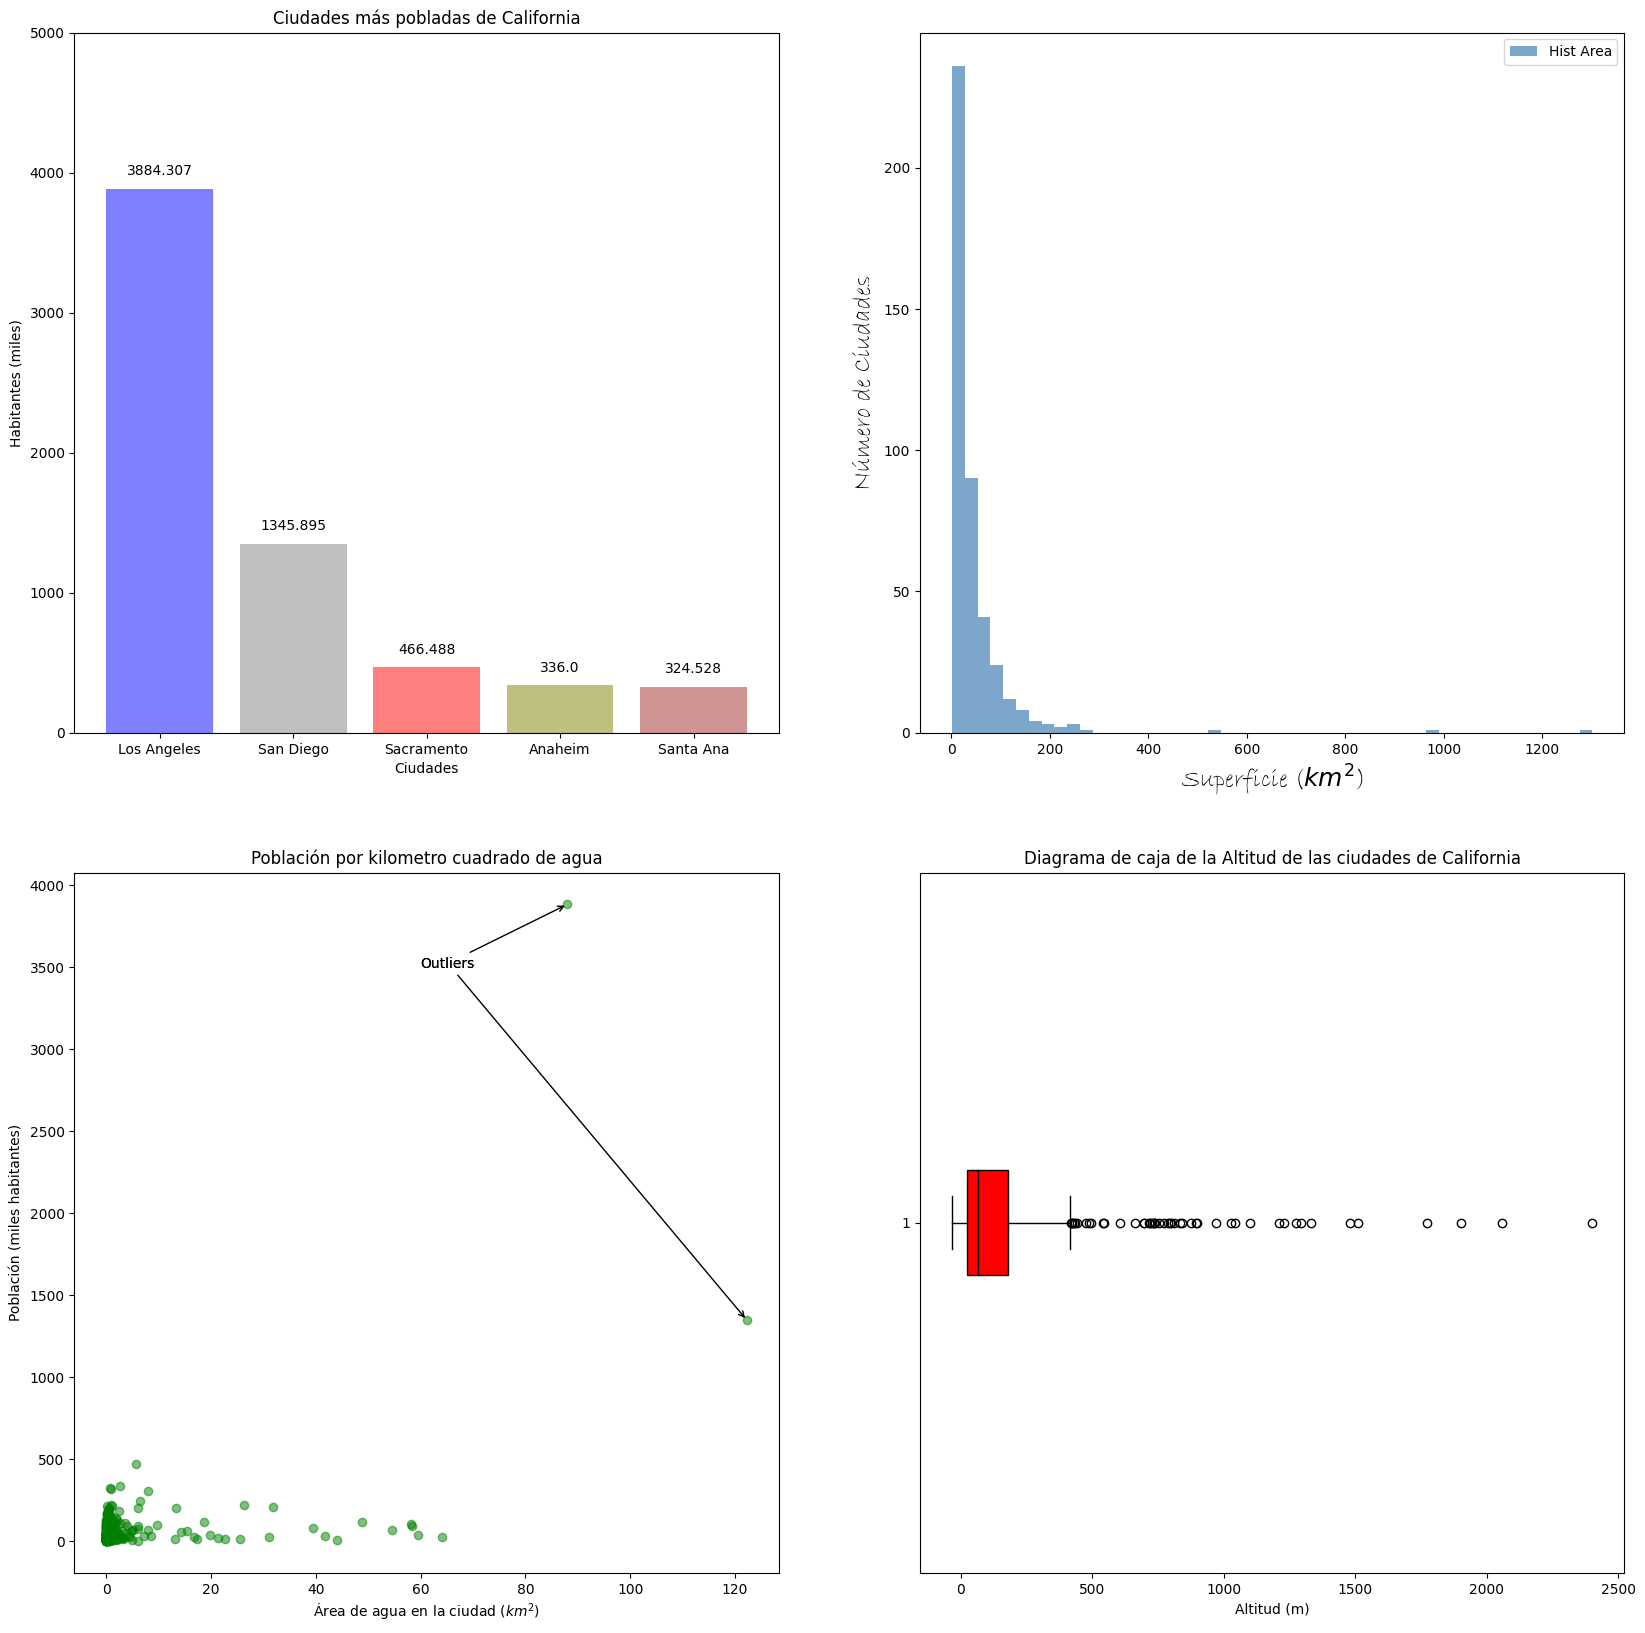

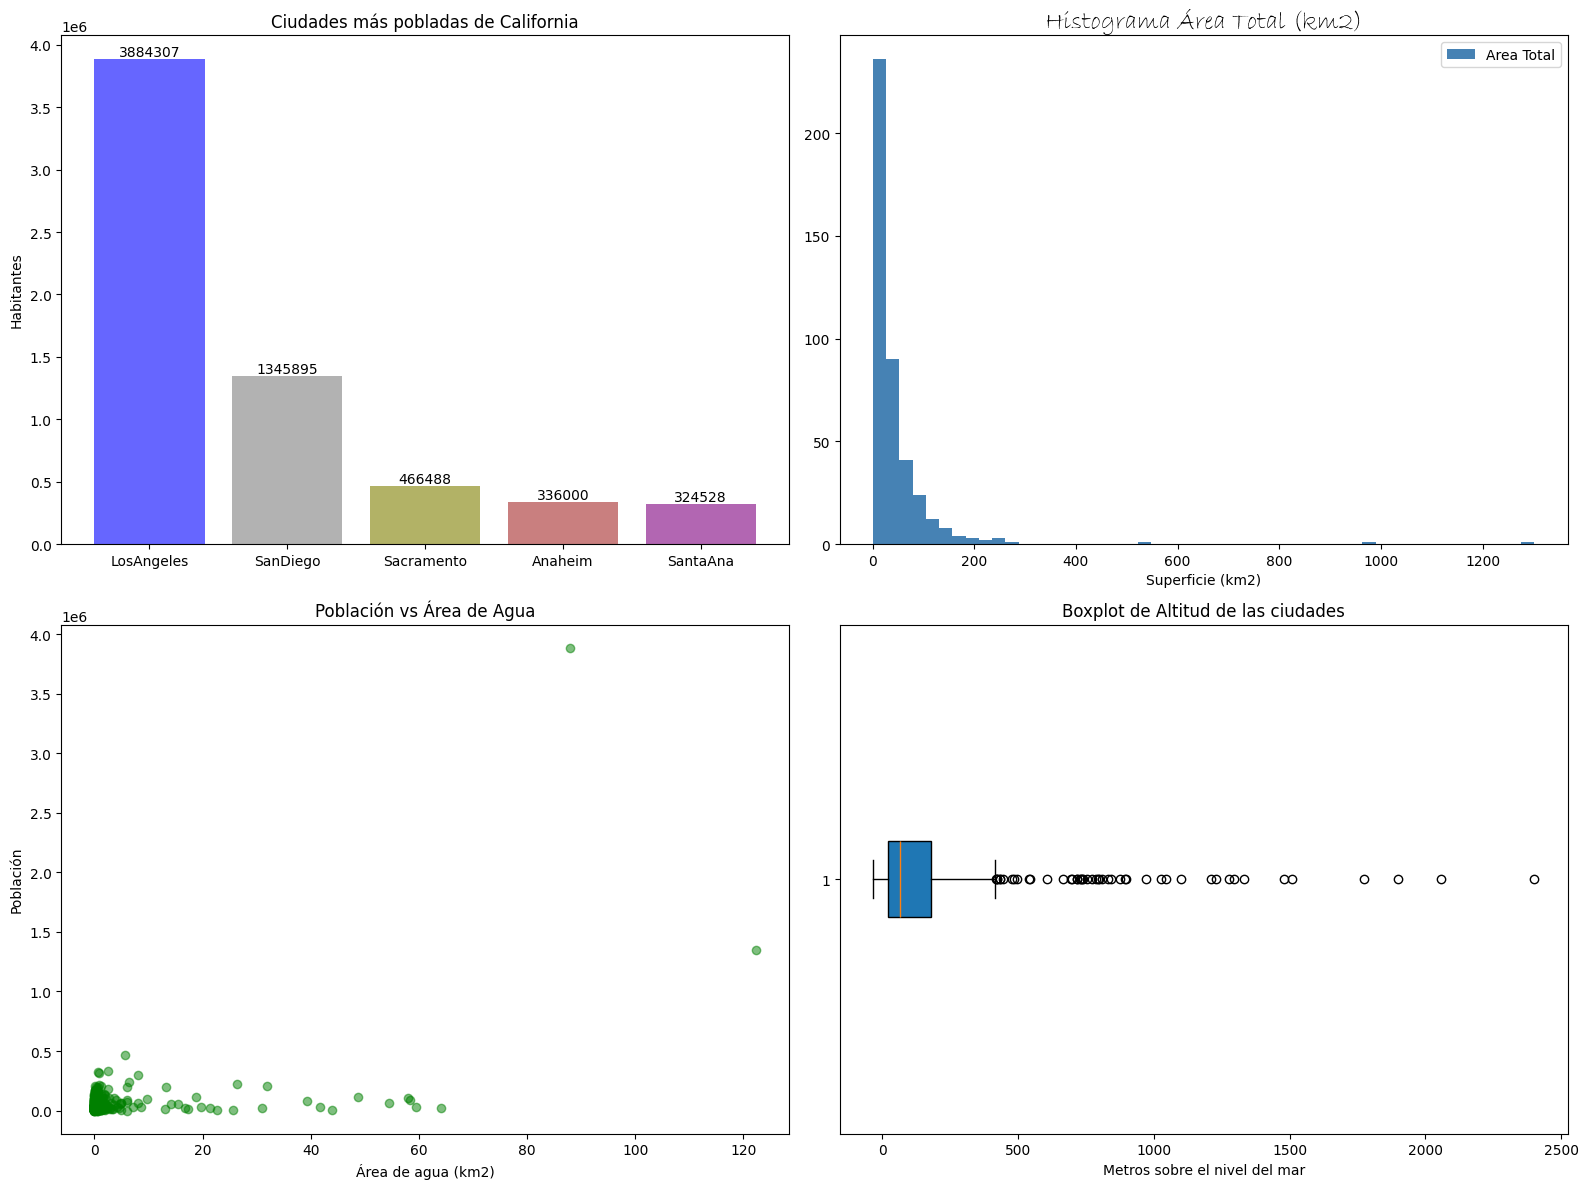

In [8]:
# 1. Preparación de datos para el gráfico de barras (Top 5 ciudades más pobladas)
cities_top_pop = df_clean.sort_values(by="population_total", ascending=False).head(5)
colors = ['blue', 'gray', 'olive', 'brown', 'purple'] # Definimos colores para las barras

# 2. Configuración del lienzo (Figure) y los ejes (Axes)
# Creamos una matriz de gráficos de 2 filas x 2 columnas
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# --- GRÁFICO 1 (Arriba Izquierda): Ciudades más pobladas ---
# Posición: ax[0, 0]
bars = ax[0, 0].bar(cities_top_pop['city'], cities_top_pop['population_total'], 
                    color=colors, alpha=0.6) # alpha es la transparencia
ax[0, 0].set_title("Ciudades más pobladas de California")
ax[0, 0].set_ylabel("Habitantes")

# Añadir las etiquetas de texto encima de las barras
for bar in bars:
    height = bar.get_height()
    ax[0, 0].text(bar.get_x() + bar.get_width()/2, height, 
                  f'{int(height)}', 
                  ha='center', va='bottom') # ha='center' centra el texto horizontalmente

# --- GRÁFICO 2 (Arriba Derecha): Histograma del área total ---
# Posición: ax[0, 1]
# Definimos el diccionario de fuente para este gráfico específico
font_config = {'family': 'Bradley Hand ITC', 'size': 18}

ax[0, 1].hist(df_clean['area_total_km2'], bins=50, color='steelblue', label='Area Total')
ax[0, 1].set_title("Histograma Área Total (km2)", fontdict=font_config)
ax[0, 1].set_xlabel("Superficie (km2)")
ax[0, 1].legend()

# --- GRÁFICO 3 (Abajo Izquierda): Scatter Área Agua vs Población ---
# Posición: ax[1, 0]
ax[1, 0].scatter(df_clean['area_water_km2'], df_clean['population_total'], 
                 alpha=0.5, color='green')
ax[1, 0].set_title("Población vs Área de Agua")
ax[1, 0].set_xlabel("Área de agua (km2)")
ax[1, 0].set_ylabel("Población")

# --- GRÁFICO 4 (Abajo Derecha): Boxplot de la altura ---
# Posición: ax[1, 1]
# elevation_m es la altura en metros
ax[1, 1].boxplot(df_clean['elevation_m'], vert=False, patch_artist=True) # vert=False para hacerlo horizontal si prefieres, o True vertical
ax[1, 1].set_title("Boxplot de Altitud de las ciudades")
ax[1, 1].set_xlabel("Metros sobre el nivel del mar")

# Ajuste final para que no se solapen los títulos
plt.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [9]:
# Guardar la figura actual
fig.savefig("mi_practica_visualizacion.png", dpi=300) 

print("Imagen guardada correctamente como 'mi_practica_visualizacion.png'")

Imagen guardada correctamente como 'mi_practica_visualizacion.png'
